# **FundusGuard AI**

model p1 using ResNet-50

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

{}

In [1]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# **Collect Dataset 1**

In [2]:
!kaggle datasets download -d arnavjain1/glaucoma-datasets

!unzip glaucoma-datasets.zip -d glaucoma_dataset

Streaming output truncated to the last 5000 lines.
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0207.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0208.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0209.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0210.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0211.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0212.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0213.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0214.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0215.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0216.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0217.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0218.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0219.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0220.png

**File structure:**

**Dataset 1 (arnavjain1/glaucoma-datasets):**

+ glaucoma_dataset
  + G1020
    + Images
      - image_0.jpg
      - image_0.json
      - image_1.jpg
      - image_1.json
      
      .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + NerveRemoved_Images
    - G1020.CSV
  + ORIGA
    + Images
        - image_0.jpg
        - image_0.json
        - image_1.jpg
        - image_1.json
        
        .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + Semi-automatic-annotations
    - OrigaList.CSV
  + REFUGE
  + MODELS
    - refug_clf.pkl
    - refuge_segmentation.pth



# **Preprocessing for Dataset 1**

In [3]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from PIL import Image

In [4]:
SOURCE_PATH = "glaucoma_dataset"
DEST_PATH = "dataset"
ROI_DEST_PATH = "dataset/roi"

classes = ["glaucoma", "normal"]
splits = ["train", "val", "test"]

In [5]:
# consider the RGB image for dataset
def convert_to_jpg(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")
    dst_path = os.path.splitext(dst_path)[0] + ".jpg"
    img.save(dst_path, "JPEG", quality=95)

In [6]:
def process_dataset(source_folder, csv_file, output_root=DEST_PATH, roi_output_root=ROI_DEST_PATH):

    csv_path = os.path.join(source_folder, csv_file)
    df = pd.read_csv(csv_path)

    print("\nProcessing:", source_folder)

    if "G1020" in source_folder:
        image_col = "imageID"
        label_col = "binaryLabels"
        images_folder = os.path.join(source_folder, "Images")

        roi_folders = [
            os.path.join(source_folder, "Images_Cropped"),
            os.path.join(source_folder, "Images_Cropped", "img")
        ]

    elif "ORIGA" in source_folder:
        image_col = "Filename"
        label_col = "Glaucoma"
        images_folder = os.path.join(source_folder, "Images_Cropped")

        roi_folders = [
            os.path.join(source_folder, "Images_Cropped")
        ]

    else:
        raise ValueError("Unknown dataset")

    images = df[image_col].astype(str).str.strip().values
    labels = df[label_col].astype(int).values

    # I am Separate small classes (less than 2 samples)
    class_counts = Counter(labels)
    print("Class Distribution:", class_counts)

    valid_images = []
    valid_labels = []
    roi_paths = []

    # for img, lbl in zip(images, labels):
    #     img_path = os.path.join(images_folder, img)

    #     if os.path.exists(img_path):
    #         valid_images.append(img_path)
    #         valid_labels.append(lbl)

    extensions = [".jpg", ".jpeg", ".png", ".bmp"]

    for img, lbl in zip(images, labels):
        base_name = os.path.splitext(img)[0]
        full_path = None
        for ext in extensions:
            p = os.path.join(images_folder, base_name + ext)
            if os.path.exists(p):
                full_path = p
                break

        if full_path is None:
            print("Missing full:", img)
            continue

        roi_path = None
        for roi_folder in roi_folders:
            for ext in extensions:
                p = os.path.join(roi_folder, base_name + ext)
                if os.path.exists(p):
                    roi_path = p
                    break
            if roi_path:
                break

        valid_images.append(full_path)
        valid_labels.append(lbl)
        roi_paths.append(roi_path)  # may be None

    print("Valid images found:", len(valid_images))

    class_counts = Counter(valid_labels)
    small_classes = [cls for cls, count in class_counts.items() if count < 2]

    print("Small classes:", small_classes)

    train_imgs, train_lbls = [], []
    valid_imgs, valid_lbls = [], []

    for img, lbl in zip(valid_images, valid_labels):
        if lbl in small_classes:
            train_imgs.append(img)
            train_lbls.append(lbl)
        else:
            valid_imgs.append(img)
            valid_lbls.append(lbl)

    # Train (60%)
    X_train, X_temp, y_train, y_temp, roi_train, roi_temp = train_test_split(
        valid_images, valid_labels, roi_paths,
        test_size=0.4,
        stratify=valid_labels,
        random_state=42
    )

    # Validation (10%) and Test (30%)
    X_val, X_test, y_val, y_test, roi_val, roi_test = train_test_split(
        X_temp, y_temp, roi_temp,
        test_size=0.75,
        stratify=y_temp,
        random_state=42
    )

    # At last add small class samples fully to the train
    X_train += train_imgs
    y_train += train_lbls

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    for root in [output_root, roi_output_root]:
        for split in splits:
            for cls in classes:
                os.makedirs(os.path.join(root, split, cls), exist_ok=True)

    # just doing copy past samples (not touch the original)
    def copy_files(images, labels, roi_list, split_name):
        for img, lbl, roi_img in zip(images, labels, roi_list):
            class_name = "glaucoma" if lbl == 1 else "normal"

            dst = os.path.join(
                output_root,
                split_name,
                class_name,
                os.path.basename(img)
            )

            ext = os.path.splitext(img)[1].lower()

            if ext in [".jpg", ".jpeg"]:
                shutil.copy(img, dst)
            elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                convert_to_jpg(img, dst)

            if roi_img:
                dst_roi = os.path.join(
                    roi_output_root,
                    split_name,
                    class_name,
                    os.path.basename(img)
                )
                if ext in [".jpg", ".jpeg"]:
                  shutil.copy(img, dst_roi)
                elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                  convert_to_jpg(img, dst_roi)

    copy_files(X_train, y_train, roi_train, "train")
    copy_files(X_val, y_val, roi_val, "val")
    copy_files(X_test, y_test, roi_test, "test")

    print("Dataset prepared successfully!")

In [7]:
# process_dataset(
#     os.path.join(SOURCE_PATH, "G1020"),
#     "G1020.csv",
#     "Images_Cropped"
# )

# process_dataset(
#     os.path.join(SOURCE_PATH, "ORIGA"),
#     "OrigaList.csv",
#     "origa_info.csv"
#     "Images_Cropped"
# )

# print("Dataset split into Train, Test, Val successfully!")

process_dataset(
    os.path.join(SOURCE_PATH, "G1020"),
    "G1020.csv"
)

process_dataset(
    os.path.join(SOURCE_PATH, "ORIGA"),
    "OrigaList.csv"
)

print("Dataset split into Train, Test, Val successfully!")


Processing: glaucoma_dataset/G1020
Class Distribution: Counter({np.int64(0): 724, np.int64(1): 296})
Valid images found: 1020
Small classes: []
Train: 612
Validation: 102
Test: 306
Dataset prepared successfully!

Processing: glaucoma_dataset/ORIGA
Class Distribution: Counter({np.int64(0): 482, np.int64(1): 168})
Valid images found: 650
Small classes: []
Train: 390
Validation: 65
Test: 195
Dataset prepared successfully!
Dataset split into Train, Test, Val successfully!


Not need, so i delete this:
  + Images_Cropped/
  + origa_info.csvImages_Cropped/


In [ ]:
shutil.rmtree("Images_Cropped", ignore_errors=True)
shutil.rmtree("origa_info.csvImages_Cropped", ignore_errors=True)

**Download the Preprocessed Dataset**

In [ ]:
from google.colab import files

shutil.make_archive("dataset", 'zip', "dataset")

#files.download("dataset.zip")

'/content/dataset.zip'

# **Collect Dataset 2**

In [8]:
#https://www.kaggle.com/datasets/sshikamaru/glaucoma-detection

!kaggle datasets download -d sshikamaru/glaucoma-detection

!unzip glaucoma-detection.zip -d glaucoma-detection

Dataset URL: https://www.kaggle.com/datasets/sshikamaru/glaucoma-detection
License(s): CC0-1.0
100% 402M/402M [00:07<00:00, 57.6MB/s]

Archive:  glaucoma-detection.zip
  inflating: glaucoma-detection/ACRIMA/Images/Im001_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im002_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im003_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im004_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im005_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im006_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im007_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im008_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im009_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im010_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im011_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im012_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im013_

**File Structure:**

**Dataset 2 (sshikamaru/glaucoma-detection):**

  + glaucoma-detection/
    + ACRIMA/
      + Images/
        - Im001_ARIMA.jpg
        - Im002_ARIMA.jpg
        - Im003_ARIMA.jpg
        
        .....
    + Fundus_Train_Val_Data/
      + Fundus_Scanes_Sorted/
        + Train/
          + Glaucoma_Negative/
            - 001.jpg
            - 002.jpg
            - 003.jpg
            
            .....
          + Glaucoma_Positive/
            - 036.jpg
            - 041.jpg
            - 069.jpg
            
            .....
        + Validation/
          + Glaucoma_Negative/
            - 483.jpg
            - 488.jpg
            - 491.jpg
            
            ......
          + Glaucoma_Positive/
            - 600.jpg
            - 605.jpg
            - 609.jpg
            
            ......
    + ORIGA/
      + ORIGA/
        + Images/
          - 001.jpg
          - 002.jpg
          - 004.jpg
          
          .......
        + Semi-automatic-annotation/
          - 001.mat
          - 002.mat
          - 004.mat
          
          .......
        - OrigaList.mat
        - TestC2D.asv
        - TestC2D.m
        - readme.txt
    - glaucoma.csv
    

# **Create New Dataset** with 1 and 2

In [9]:
import os
import shutil
from pathlib import Path

dataset1_path = "dataset"
dataset2_path = "dataset_v2"

In [10]:
raw_glaucoma = os.path.join(dataset2_path, "raw", "glaucoma")
raw_normal = os.path.join(dataset2_path, "raw", "normal")

# ROI folders
roi_glaucoma = os.path.join(dataset2_path, "roi_raw", "glaucoma")
roi_normal = os.path.join(dataset2_path, "roi_raw", "normal")

os.makedirs(raw_glaucoma, exist_ok=True)
os.makedirs(raw_normal, exist_ok=True)
os.makedirs(roi_glaucoma, exist_ok=True)
os.makedirs(roi_normal, exist_ok=True)

g_count = 0
n_count = 0

m_r_g_count = 0
m_r_n_count = 0

for split in ["train", "val", "test"]:

    print(f"\nWork on {split}")

    img_g_path = os.path.join(dataset1_path, split, "glaucoma")
    img_n_path = os.path.join(dataset1_path, split, "normal")

    roi_g_path = os.path.join(dataset1_path, "roi", split, "glaucoma")
    roi_n_path = os.path.join(dataset1_path, "roi", split, "normal")

    if os.path.exists(img_g_path):
        for file in os.listdir(img_g_path):

            src_img = os.path.join(img_g_path, file)
            src_roi = os.path.join(roi_g_path, file)

            if os.path.isfile(src_img):

                new_name = f"d1_g_{g_count:05d}.jpg"

                dst_img = os.path.join(raw_glaucoma, new_name)
                shutil.copy(src_img, dst_img)

                # Copy ROI if exists
                if os.path.exists(src_roi):
                    dst_roi = os.path.join(roi_glaucoma, new_name)
                    shutil.copy(src_roi, dst_roi)
                else:
                    m_r_g_count += 1

                g_count += 1

    if os.path.exists(img_n_path):
        for file in os.listdir(img_n_path):

            src_img = os.path.join(img_n_path, file)
            src_roi = os.path.join(roi_n_path, file)

            if os.path.isfile(src_img):

                new_name = f"d1_n_{n_count:05d}.jpg"

                dst_img = os.path.join(raw_normal, new_name)
                shutil.copy(src_img, dst_img)

                # Copy ROI if exists
                if os.path.exists(src_roi):
                    dst_roi = os.path.join(roi_normal, new_name)
                    shutil.copy(src_roi, dst_roi)
                else:
                    m_r_n_count += 1

                n_count += 1

print("\nDataset-1 + ROI extraction complete!")
print("Glaucoma:", g_count)
print("Normal:", n_count)
print("\nMissing ROI: \n", "Glaucoma = ", m_r_g_count, "Normal = ", m_r_n_count)


Work on train

Work on val

Work on test

Dataset-1 + ROI extraction complete!
Glaucoma: 464
Normal: 1206

Missing ROI: 
 Glaucoma =  0 Normal =  0


## ROI segmentation model help to create the missing roi samples

In [12]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.8 MB/s eta 0:00:00


In [13]:
import segmentation_models_pytorch as smp
import torch
import cv2
import numpy as np
from PIL import Image

In [17]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seg_model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights=None,
    in_channels=3,
    classes=2,
    activation='sigmoid'
)

checkpoint = torch.load("best_seg.pth", map_location=device)

filtered_checkpoint = {
    k: v for k, v in checkpoint.items()
    if not ("total_ops" in k or "total_params" in k)
}

seg_model.load_state_dict(filtered_checkpoint, strict=True)

# seg_model.load_state_dict(
#     torch.load("best_seg.pth", map_location=device)
# )

seg_model.to(device)
seg_model.eval()

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 40, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          40, 40, kernel_size=(3, 3), stride=[1, 1], groups=40, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          40, 10, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          10, 40, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Ident

In [18]:
def create_roi_using_segmentation(image_path, model, device, threshold_od=0.90, threshold_oc=0.10):

    # Load image
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    original_h, original_w = img_np.shape[:2]

    # Preprocess for U-Net
    img_tensor = torch.from_numpy(img_np).float() / 255.0
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0).to(device)

    # Predict segmentation
    with torch.no_grad():
        logits = model(img_tensor)

        # OD + OC masks
        od_mask = (logits[0, 0] >= threshold_od).cpu().numpy().astype(np.uint8)
        oc_mask = (logits[0, 1] >= threshold_oc).cpu().numpy().astype(np.uint8)

    # Combine masks
    # combined_mask = (((0.5 * od_mask) + (0.5 * oc_mask))* 255).astype(np.uint8)
    combined_mask = np.maximum(od_mask, oc_mask).astype(np.uint8) * 255

    kernel = np.ones((5,5), np.uint8)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)

    # Find ROI bounding box
    contours, _ = cv2.findContours(
        combined_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        # fallback: return original image resized
        return img_np

    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))

    # Add padding
    pad = 20
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, original_w)
    y2 = min(y + h + pad, original_h)

    # Crop ROI
    roi = img_np[y1:y2, x1:x2]

    # Resize back (important for my ResNet consistency)
    roi = cv2.resize(roi, (224, 224))

    return roi

# **Collect raw images from Dataset 2** in labeled folder / **Preprocessing for Dataset 2**

In [19]:
import os
import shutil
import pandas as pd


dataset2_root = "glaucoma-detection"

fundus_root = os.path.join(dataset2_root,
                           "Fundus_Train_Val_Data",
                           "Fundus_Scanes_Sorted")

origa_images = os.path.join(dataset2_root,
                            "ORIGA",
                            "ORIGA",
                            "Images")

csv_path = os.path.join(dataset2_root, "glaucoma.csv")


helper_root = "data_helper"

In [20]:
glaucoma_dir = os.path.join(helper_root, "glaucoma")
normal_dir = os.path.join(helper_root, "normal")

os.makedirs(glaucoma_dir, exist_ok=True)
os.makedirs(normal_dir, exist_ok=True)

glaucoma_roi_dir = os.path.join(helper_root, "roi_glaucoma")
normal_roi_dir = os.path.join(helper_root, "roi_normal")

os.makedirs(glaucoma_roi_dir, exist_ok=True)
os.makedirs(normal_roi_dir, exist_ok=True)

# TEMP folder (important for 1:1)
temp_normal_dir = "temp_normal"

os.makedirs(temp_normal_dir, exist_ok=True)

g_count = 0
n_count = 0

temp_count = 0

NEEDED_NORMAL = 237

for split in ["Train", "Validation"]:

    print(f"Work on {split} folder\n")
    pos_path = os.path.join(fundus_root, split, "Glaucoma_Positive")
    neg_path = os.path.join(fundus_root, split, "Glaucoma_Negative")

    # glaucoma images
    if os.path.exists(pos_path):
        for img in os.listdir(pos_path):

            src = os.path.join(pos_path, img)

            if os.path.isfile(src):

                new_name = f"d2_fundus_g_{g_count:05d}.jpg"
                dst = os.path.join(glaucoma_dir, new_name)

                shutil.copy(src, dst)

                # CREATE ROI USING U-NET
                roi_crop = create_roi_using_segmentation(
                    src,
                    seg_model,
                    device
                )

                roi_dst = os.path.join(
                    glaucoma_roi_dir,
                    new_name
                )

                cv2.imwrite(
                    roi_dst,
                    cv2.cvtColor(roi_crop, cv2.COLOR_RGB2BGR)
                )

                g_count += 1

    # normal images
    if os.path.exists(neg_path):
        for img in os.listdir(neg_path):

            src = os.path.join(neg_path, img)

            if os.path.isfile(src):

                new_name = f"d2_fundus_n_{n_count:05d}.jpg"
                dst = os.path.join(normal_dir, new_name)

                shutil.copy(src, dst)
                # CREATE ROI USING U-NET
                roi_crop = create_roi_using_segmentation(
                    src,
                    seg_model,
                    device
                )

                roi_dst = os.path.join(
                    normal_roi_dir,
                    new_name
                )

                cv2.imwrite(
                    roi_dst,
                    cv2.cvtColor(roi_crop, cv2.COLOR_RGB2BGR)
                )

                n_count += 1

                # I am Save some sample to temp (only first 237)
                if temp_count < NEEDED_NORMAL:
                    temp_name = f"d2_fundus_n_{temp_count:05d}.jpg"
                    temp_dst = os.path.join(temp_normal_dir, temp_name)
                    shutil.copy(src, temp_dst)
                    temp_count += 1

                n_count += 1

df = pd.read_csv(csv_path)

for i, row in df.iterrows():

    filename = row["Filename"]
    label = row["Glaucoma"]

    src = os.path.join(origa_images, filename)

    if not os.path.exists(src):
        continue

    if label == 1:
        new_name = f"d2_origa_g_{g_count:05d}.jpg"
        dst = os.path.join(glaucoma_dir, new_name)
        shutil.copy(src, dst)
        roi_crop = create_roi_using_segmentation(
            src,
            seg_model,
            device
        )

        roi_dst = os.path.join(
            glaucoma_roi_dir,
            new_name
        )

        cv2.imwrite(
            roi_dst,
            cv2.cvtColor(roi_crop, cv2.COLOR_RGB2BGR)
        )
        g_count += 1

    else:
        new_name = f"d2_origa_n_{n_count:05d}.jpg"
        dst = os.path.join(normal_dir, new_name)
        shutil.copy(src, dst)
        roi_crop = create_roi_using_segmentation(
            src,
            seg_model,
            device
        )

        roi_dst = os.path.join(
            normal_roi_dir,
            new_name
        )

        cv2.imwrite(
            roi_dst,
            cv2.cvtColor(roi_crop, cv2.COLOR_RGB2BGR)
        )
        n_count += 1

print("Extraction Complete!\n")

print("Glaucoma images collected:", g_count)
print("Normal images collected:", n_count)
print("Temp Normal Saved:", temp_count)

print("\nSaved inside:")
print(helper_root)

'''
Previous
--------------------------------------
Work on Train folder

Work on Validation folder

Extraction Complete!

Glaucoma images collected: 336
Normal images collected: 485

Saved inside:
data_helper
'''

Work on Train folder

Work on Validation folder

Extraction Complete!

Glaucoma images collected: 336
Normal images collected: 1446
Temp Normal Saved: 237

Saved inside:
data_helper


'\nPrevious\n--------------------------------------\nWork on Train folder\n\nWork on Validation folder\n\nExtraction Complete!\n\nGlaucoma images collected: 336\nNormal images collected: 485\n\nSaved inside:\ndata_helper\n'

In [21]:
# Delete normal images from data_helper to make it 1:1

normal_dir = "data_helper/normal"

files = os.listdir(normal_dir)

print("Normal images before deletion:", len(files))

for f in files:
    path = os.path.join(normal_dir, f)

    if os.path.isfile(path):
        os.remove(path)

print("Normal images after deletion:", len(os.listdir(normal_dir)))

Normal images before deletion: 964
Normal images after deletion: 0


# **Merge both dataset into dataset_v2**

In [22]:
helper_root = "data_helper"
dataset_v2_root = "dataset_v2/raw"

helper_glaucoma = os.path.join(helper_root, "glaucoma")
helper_normal = os.path.join(helper_root, "normal")

dest_glaucoma = os.path.join(dataset_v2_root, "glaucoma")
dest_normal = os.path.join(dataset_v2_root, "normal")

os.makedirs(dest_glaucoma, exist_ok=True)
os.makedirs(dest_normal, exist_ok=True)


In [23]:
g_count = len(os.listdir(dest_glaucoma))
n_count = len(os.listdir(dest_normal))


for img in os.listdir(helper_glaucoma):
    src = os.path.join(helper_glaucoma, img)
    if os.path.isfile(src):
        new_name = f"d2_g_{g_count:05d}.jpg"
        dst = os.path.join(dest_glaucoma, new_name)

        shutil.copy(src, dst)

        g_count += 1

for img in os.listdir(helper_normal):
    src = os.path.join(helper_normal, img)
    if os.path.isfile(src):
        new_name = f"d2_n_{n_count:05d}.jpg"
        dst = os.path.join(dest_normal, new_name)

        shutil.copy(src, dst)

        n_count += 1

print("Merge Complete!\n")

print("Total glaucoma images now:", len(os.listdir(dest_glaucoma)))
print("Total normal images now:", len(os.listdir(dest_normal)))

Merge Complete!

Total glaucoma images now: 800
Total normal images now: 1206


# **Data Spliting into Train, Test, Val**

In [24]:
import os
import shutil
from collections import Counter
from sklearn.model_selection import train_test_split
from PIL import Image

In [25]:
raw_root = "dataset_v2/raw"
roi_root = "dataset_v2/roi_raw"

output_root = "dataset_v2"
roi_output_root = "dataset_v2/roi"

classes = ["glaucoma", "normal"]
splits = ["train", "val", "test"]

valid_images = []
valid_labels = []
roi_paths = []

In [26]:
for cls in classes:
    class_path = os.path.join(raw_root, cls)
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)

        if not img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")):
            continue

        valid_images.append(img_path)

        if cls == "glaucoma":
            valid_labels.append(1)
        else:
            valid_labels.append(0)

        roi_img = os.path.join(roi_root, cls, img)

        if os.path.exists(roi_img):
            roi_paths.append(roi_img)
        else:
            roi_paths.append(None)


print("Total images:", len(valid_images))


class_counts = Counter(valid_labels)

small_classes = [cls for cls, count in class_counts.items() if count < 2]

print("Small classes:", small_classes)

train_imgs, train_lbls, train_roi = [], [], []
valid_imgs, valid_lbls, valid_roi = [], [], []

for img, lbl, roi in zip(valid_images, valid_labels, roi_paths):

    if lbl in small_classes:
        train_imgs.append(img)
        train_lbls.append(lbl)
        train_roi.append(roi)
    else:
        valid_imgs.append(img)
        valid_lbls.append(lbl)
        valid_roi.append(roi)

X_train, X_temp, y_train, y_temp, roi_train, roi_temp = train_test_split(
    valid_images,
    valid_labels,
    valid_roi,
    # roi_paths,
    test_size=0.4,
    stratify=valid_labels,
    random_state=42
)


X_val, X_test, y_val, y_test, roi_val, roi_test = train_test_split(
    X_temp,
    y_temp,
    roi_temp,
    test_size=0.75,
    stratify=y_temp,
    random_state=42
)

X_train += train_imgs
y_train += train_lbls
roi_train += train_roi

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

for root in [output_root, roi_output_root]:
    for split in splits:
        for cls in classes:
            os.makedirs(
                os.path.join(root, split, cls),
                exist_ok=True
            )


def convert_to_jpg(src, dst):
    img = Image.open(src).convert("RGB")
    dst = os.path.splitext(dst)[0] + ".jpg"
    img.save(dst, "JPEG", quality=95)


def copy_files(images, labels, roi_list, split_name):
    for img, lbl, roi_img in zip(images, labels, roi_list):
        class_name = "glaucoma" if lbl == 1 else "normal"
        base_name = os.path.splitext(os.path.basename(img))[0] + ".jpg"
        dst = os.path.join(
            output_root,
            split_name,
            class_name,
            base_name
        )

        ext = os.path.splitext(img)[1].lower()

        if ext in [".jpg", ".jpeg"]:
            shutil.copy(img, dst)

        elif ext in [".png", ".bmp", ".tiff"]:
            convert_to_jpg(img, dst)

        if roi_img is not None:

            dst_roi = os.path.join(
                roi_output_root,
                split_name,
                class_name,
                base_name
            )

            roi_ext = os.path.splitext(roi_img)[1].lower()

            if roi_ext in [".jpg", ".jpeg"]:
                shutil.copy(roi_img, dst_roi)
            else:
                convert_to_jpg(roi_img, dst_roi)


copy_files(X_train, y_train, roi_train, "train")
copy_files(X_val, y_val, roi_val, "val")
copy_files(X_test, y_test, roi_test, "test")

print("Dataset prepared successfully!")

Total images: 2006
Small classes: []
Train: 1203
Validation: 200
Test: 603
Dataset prepared successfully!


**Copy First 237 Normal Images for 1:1 samples**
```
before augment
glaucoma = 480
normal   = 723 -> 960   # balanced for augmentation

after augment
glaucoma = 480 * 4 = 1920
normal   = 960 * 2 = 1920   # PERFECT 1:1
```

In [27]:
temp_folder = "temp_normal"
target_folder = "dataset_v2/train/normal"

os.makedirs(target_folder, exist_ok=True)

files = sorted(os.listdir(temp_folder))

existing_count = len(os.listdir(target_folder))

# copy temp file to dataset_v2
for i, img in enumerate(files):
    src = os.path.join(temp_folder, img)
    if not os.path.isfile(src):
        continue

    new_name = f"extra_n_{existing_count + i:05d}.jpg"
    dst = os.path.join(target_folder, new_name)
    shutil.copy(src, dst)

print("Temp images added:", len(files))
print("New total normal images:", len(os.listdir(target_folder)))

Temp images added: 237
New total normal images: 960


In [28]:
# Sample size
# expected: Train normal: 960 , Train glaucoma: 480
print("Train glaucoma:", len(os.listdir("dataset_v2/train/glaucoma")))
print("Train normal:", len(os.listdir("dataset_v2/train/normal")))

Train glaucoma: 480
Train normal: 960


# **Dataset Image Visiual Samples**

In [29]:
import matplotlib.pyplot as plt
import glob
import cv2

def show_grid(output_dir, rows=5, cols=5):
    image_files = glob.glob(os.path.join(output_dir, "*.jpg"))
    image_files = image_files[:rows*cols]

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        if i < len(image_files):
            img = cv2.imread(image_files[i])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(os.path.basename(image_files[i]), fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

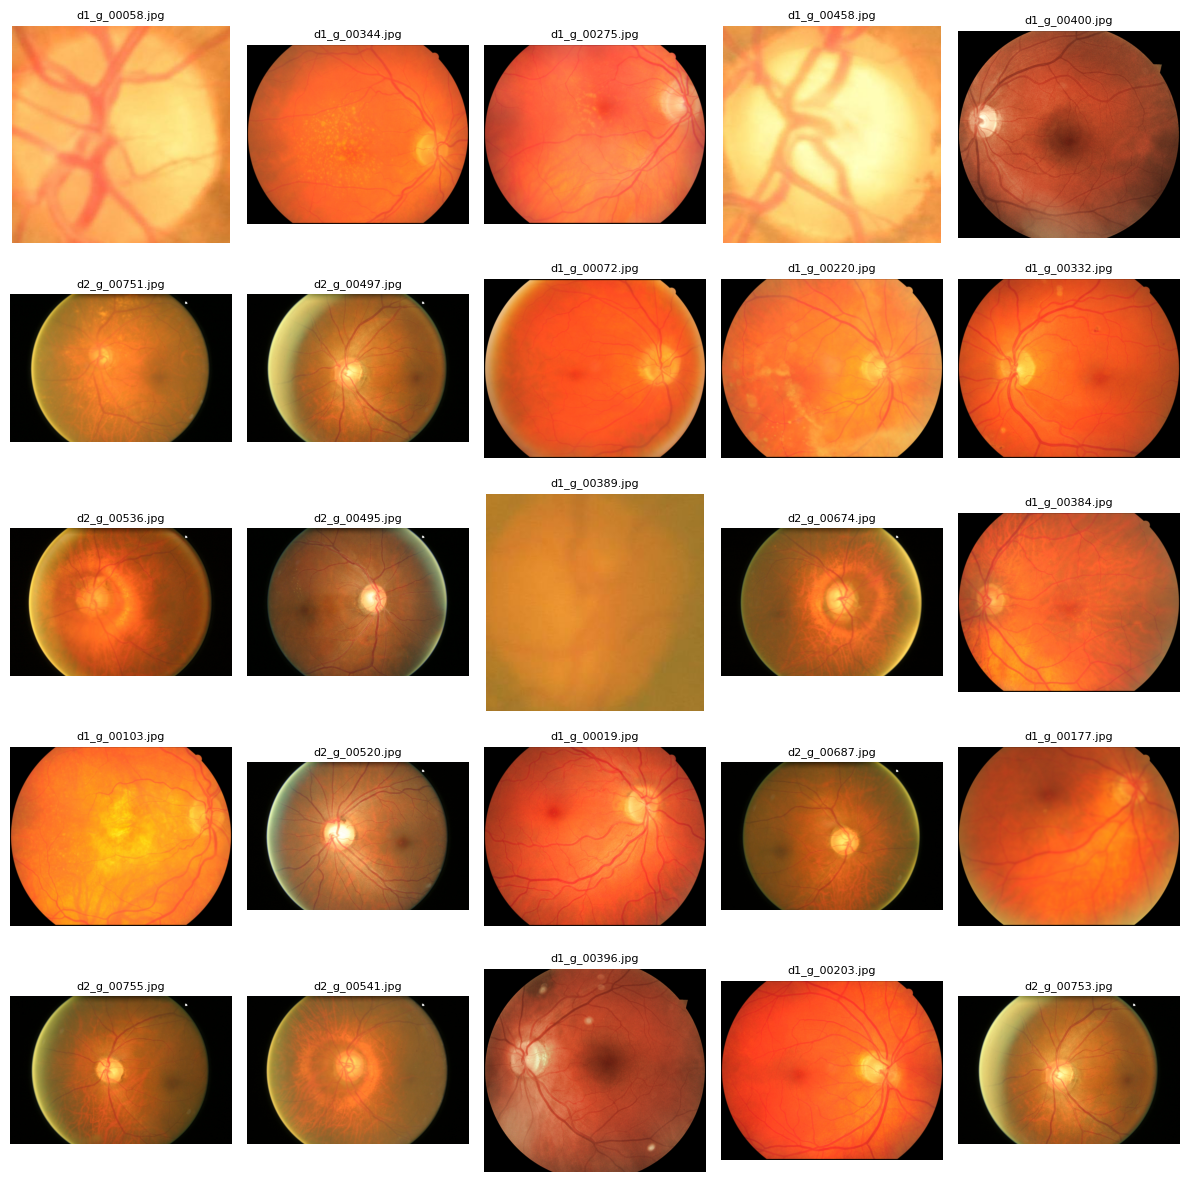

In [30]:
show_grid("dataset_v2/train/glaucoma", rows=5, cols=5)

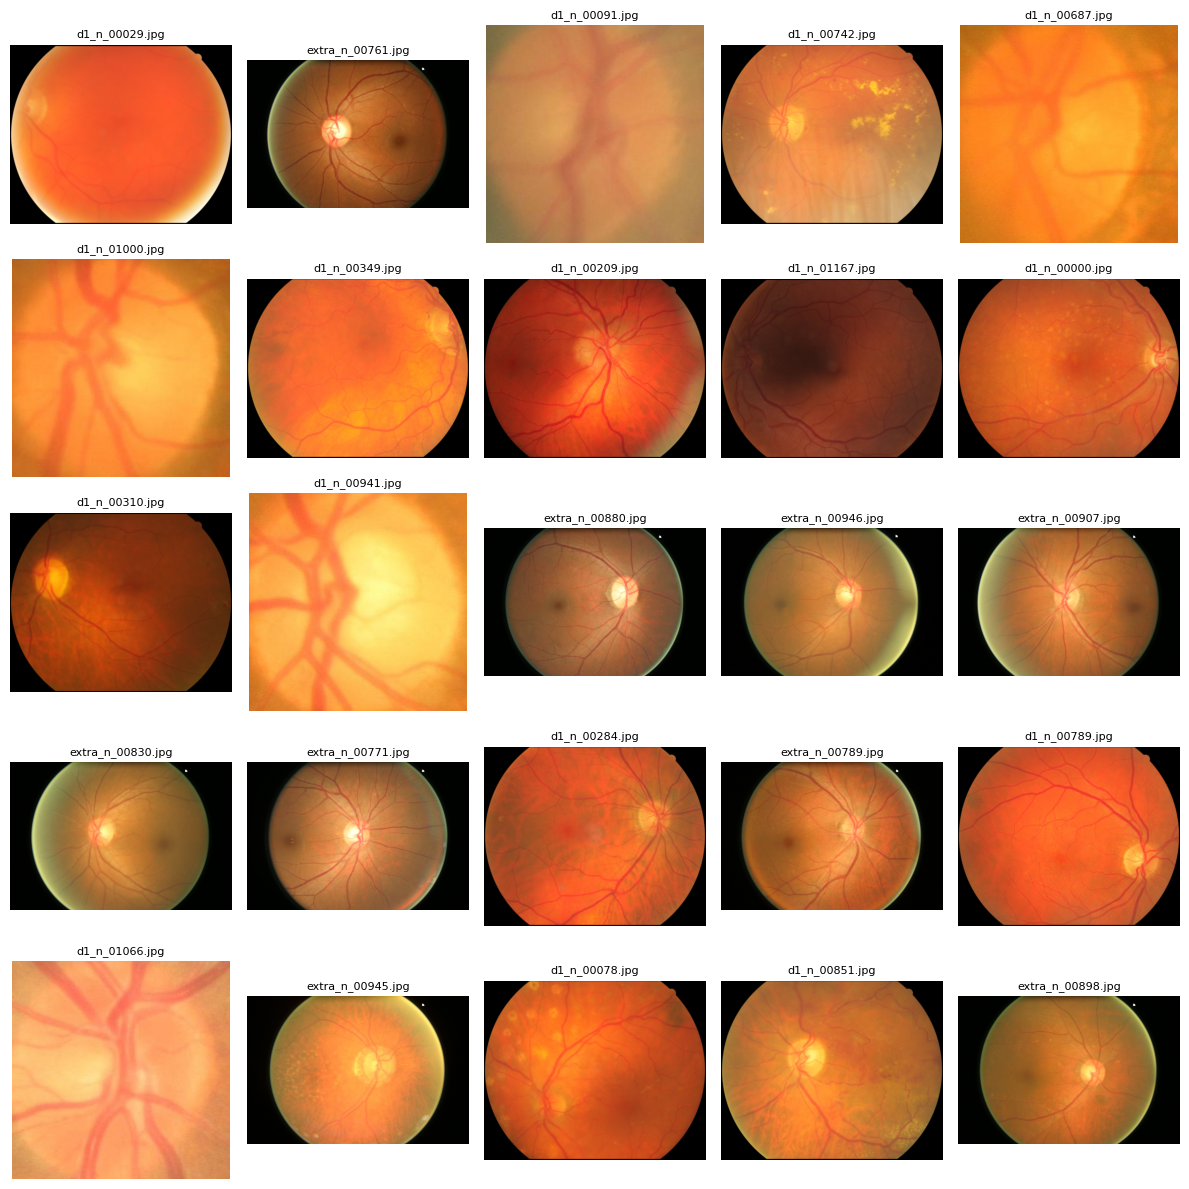

In [31]:
show_grid("dataset_v2/train/normal", rows=5, cols=5)

# **Data Augmentaion for Variation**

In [32]:
import os
import random
from PIL import Image, ImageEnhance, ImageOps
import numpy as np

In [33]:
# augment iin only train/ folder
# DATASET_PATH = "dataset/train"
# ROI_PATH = "dataset/roi/train"

DATASET_PATH = "dataset_v2/train"
ROI_PATH = "dataset_v2/roi/train"

In [34]:
def rotate(img):
    return img.rotate(random.choice([90, 180, 270]))

def flip(img):
    if random.random() > 0.5:
        return ImageOps.mirror(img)   # horizontal flip
    else:
        return ImageOps.flip(img)     # vertical flip

def brightness(img):
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def contrast(img):
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def color(img):
    enhancer = ImageEnhance.Color(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def add_noise(img):
    arr = np.array(img)
    noise = np.random.randint(0, 30, arr.shape, dtype='uint8')
    arr = np.clip(arr + noise, 0, 255)
    return Image.fromarray(arr)

augmentations = [rotate, flip, brightness, contrast, color, add_noise]


In [35]:
# def augment_dataset():
#     print("Augmenting start...")
#     for class_name in ["glaucoma", "normal"]:
#         class_path = os.path.join(DATASET_PATH, class_name)
#         print(f"Work on: {class_path}")

#         for img_name in os.listdir(class_path):
#             img_path = os.path.join(class_path, img_name)

#             if not img_name.lower().endswith(".jpg"):
#                 continue

#             img = Image.open(img_path).convert("RGB")

#             # i create 3 augmented copies per image
#             for i in range(3):
#                 aug_img = img.copy()

#                 # apply any 2 random augmentations
#                 for aug in random.sample(augmentations, 2):
#                     aug_img = aug(aug_img)

#                 new_name = f"aug_{i}_{img_name}"
#                 save_path = os.path.join(class_path, new_name)

#                 aug_img.save(save_path, "JPEG", quality=95)

#     print("Augmentation completed successfully!")

# augment_dataset()

## Class Balancing via Targeted Augmentation
def augment_dataset():
    print("Augmenting start...")
    for class_name in ["glaucoma", "normal"]:
        class_path = os.path.join(DATASET_PATH, class_name)
        roi_class_path = os.path.join(ROI_PATH, class_name)

        print(f"\nWork on: {class_path}\n")

        if class_name == "glaucoma":
            num_copies = 3   # MORE copies
        else:
            num_copies = 1   # LESS copies

        image_list = os.listdir(class_path)

        for idx, img_name in enumerate(image_list):
            img_path = os.path.join(class_path, img_name)
            roi_img_path = os.path.join(roi_class_path, img_name)

            print(f"aug: {img_path}")

            if not img_name.lower().endswith(".jpg"):
                continue

            # if not os.path.exists(roi_img_path):
            #     print("ROI missing:", img_name)
            #     continue

            img = Image.open(img_path).convert("RGB")
            roi_exists = os.path.exists(roi_img_path)

            if roi_exists:
                roi_img = Image.open(roi_img_path).convert("RGB")

            for i in range(num_copies):
                aug_img = img.copy()

                if roi_exists:
                    aug_roi = roi_img.copy()

                # SAME augmentations applied to both
                chosen_augs = random.sample(augmentations, 2)

                # apply any 2 random augmentations
                for aug in chosen_augs:
                    aug_img = aug(aug_img)
                    if roi_exists:
                        aug_roi = aug(aug_roi)

                base = os.path.splitext(img_name)[0]
                new_name = f"aug_{idx}_{i}_{base}.jpg"

                save_full = os.path.join(class_path, new_name)
                aug_img.save(save_full, "JPEG", quality=95)

                if roi_exists:
                    save_roi = os.path.join(roi_class_path, new_name)
                    aug_roi.save(save_roi, "JPEG", quality=95)
                elif img_name.startswith("d2"):
                    continue # skip dataset 2
                else:
                    print(f"ROI missing for: {img_name}")

    print("\nAugmentation completed successfully!")

augment_dataset()

Augmenting start...

Work on: dataset_v2/train/glaucoma

aug: dataset_v2/train/glaucoma/d1_g_00058.jpg
aug: dataset_v2/train/glaucoma/d1_g_00344.jpg
aug: dataset_v2/train/glaucoma/d1_g_00275.jpg
aug: dataset_v2/train/glaucoma/d1_g_00458.jpg
aug: dataset_v2/train/glaucoma/d1_g_00400.jpg
aug: dataset_v2/train/glaucoma/d2_g_00751.jpg
aug: dataset_v2/train/glaucoma/d2_g_00497.jpg
aug: dataset_v2/train/glaucoma/d1_g_00072.jpg
aug: dataset_v2/train/glaucoma/d1_g_00220.jpg
aug: dataset_v2/train/glaucoma/d1_g_00332.jpg
aug: dataset_v2/train/glaucoma/d2_g_00536.jpg
aug: dataset_v2/train/glaucoma/d2_g_00495.jpg
aug: dataset_v2/train/glaucoma/d1_g_00389.jpg
aug: dataset_v2/train/glaucoma/d2_g_00674.jpg
aug: dataset_v2/train/glaucoma/d1_g_00384.jpg
aug: dataset_v2/train/glaucoma/d1_g_00103.jpg
aug: dataset_v2/train/glaucoma/d2_g_00520.jpg
aug: dataset_v2/train/glaucoma/d1_g_00019.jpg
aug: dataset_v2/train/glaucoma/d2_g_00687.jpg
aug: dataset_v2/train/glaucoma/d1_g_00177.jpg
aug: dataset_v2/train/g

**Dataset Image Visiual Samples**

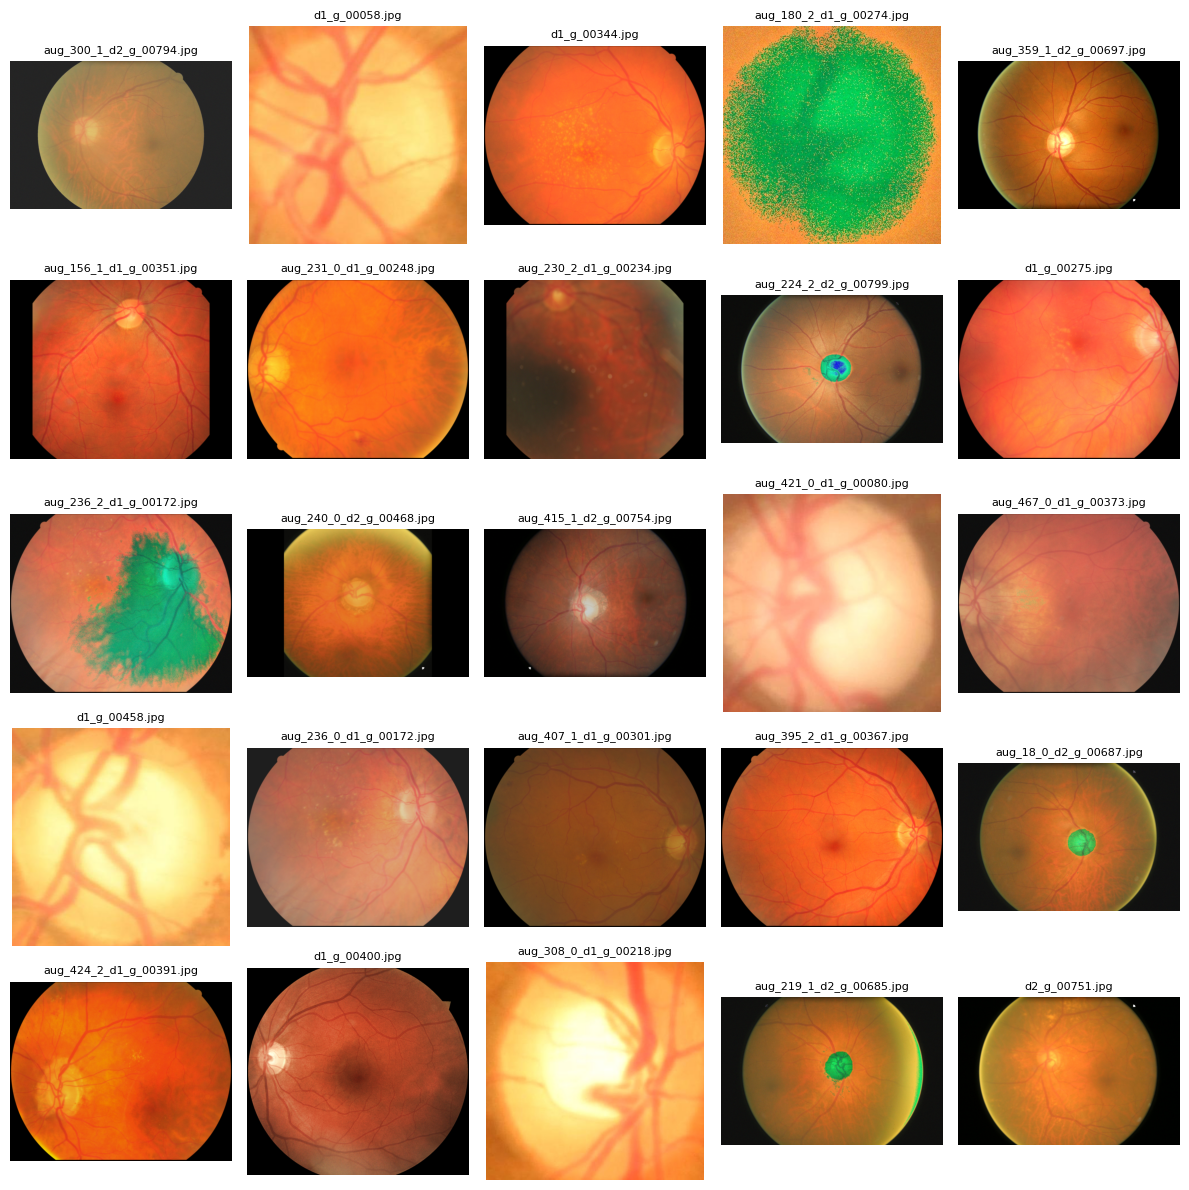

In [36]:
show_grid("dataset_v2/train/glaucoma", rows=5, cols=5)

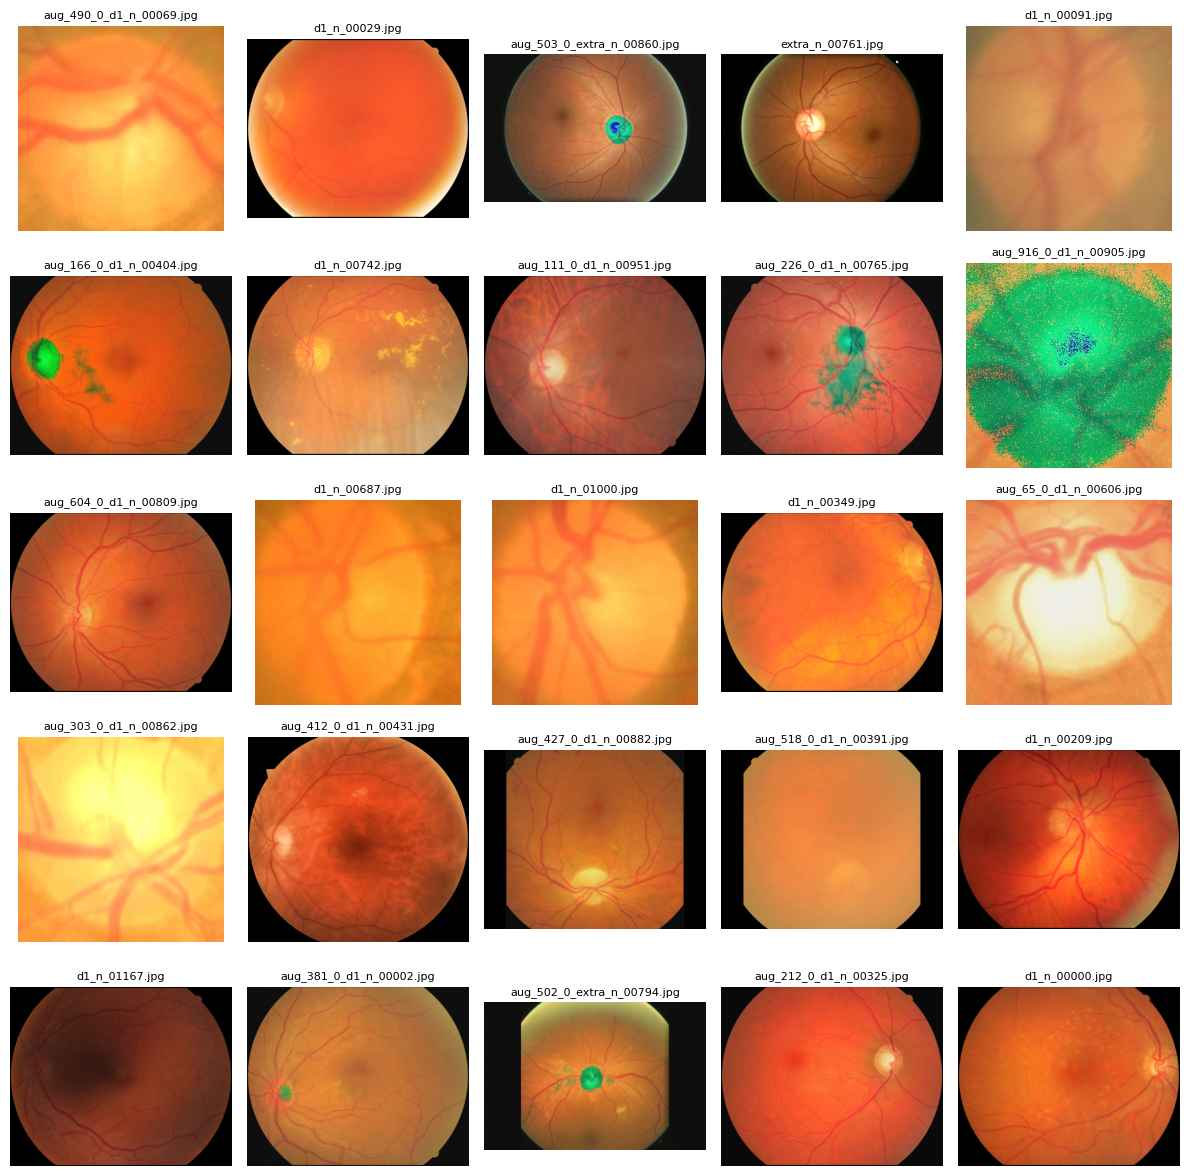

In [37]:
show_grid("dataset_v2/train/normal", rows=5, cols=5)

# **Data Distribution**

In [38]:
import os
import matplotlib.pyplot as plt

In [39]:
DATASET_PATH = "dataset_v2"

splits = ["train", "val", "test"]
classes = ["glaucoma", "normal"]

labels = []
counts = []

for split in splits:
    for cls in classes:
        path = os.path.join(DATASET_PATH, split, cls)

        num_images = len([
            f for f in os.listdir(path)
            if f.lower().endswith(".jpg")
        ])

        labels.append(f"{split}/{cls}")
        counts.append(num_images)

print(f"labels: {labels},\nCounts: {counts}")

short_labels = ["Tr-G", "Tr-N", "Va-G", "Va-N", "Te-G", "Te-N"]


labels: ['train/glaucoma', 'train/normal', 'val/glaucoma', 'val/normal', 'test/glaucoma', 'test/normal'],
Counts: [1920, 1920, 80, 120, 240, 363]


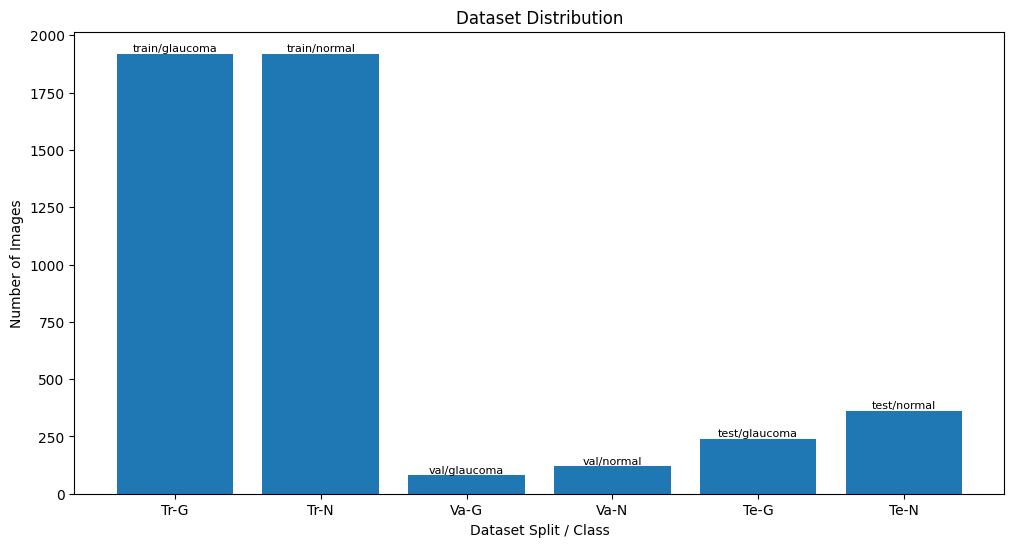

In [40]:
plt.figure(figsize=(12,6))

plt.bar(short_labels, counts)

plt.xlabel("Dataset Split / Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

for i, txt in enumerate(labels):
    plt.text(i, counts[i], txt, ha='center', va='bottom', fontsize=8)

plt.show()

**Distribution for ROI folder**

In [41]:
DATASET_PATH = "dataset_v2/roi"

splits = ["train", "val", "test"]
classes = ["glaucoma", "normal"]

labels = []
counts = []

for split in splits:
    for cls in classes:
        path = os.path.join(DATASET_PATH, split, cls)

        num_images = len([
            f for f in os.listdir(path)
            if f.lower().endswith(".jpg")
        ])

        labels.append(f"{split}/{cls}")
        counts.append(num_images)

print(f"labels: {labels},\nCounts: {counts}")

short_labels = ["Tr-G", "Tr-N", "Va-G", "Va-N", "Te-G", "Te-N"]


labels: ['train/glaucoma', 'train/normal', 'val/glaucoma', 'val/normal', 'test/glaucoma', 'test/normal'],
Counts: [1132, 1446, 50, 120, 131, 363]


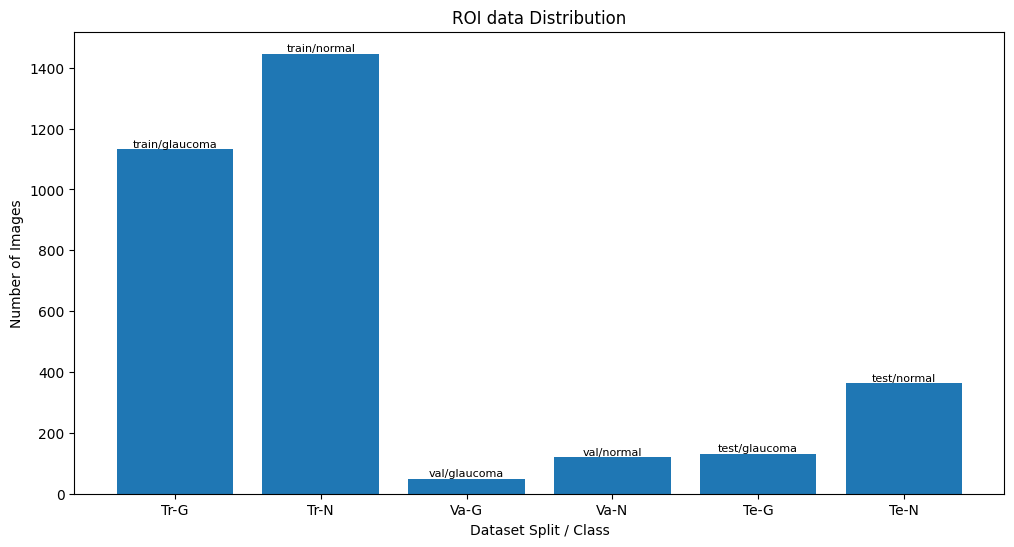

In [42]:
plt.figure(figsize=(12,6))

plt.bar(short_labels, counts)

plt.xlabel("Dataset Split / Class")
plt.ylabel("Number of Images")
plt.title("ROI data Distribution")

for i, txt in enumerate(labels):
    plt.text(i, counts[i], txt, ha='center', va='bottom', fontsize=8)

plt.show()

**Download the Augmentated Dataset**

In [ ]:
from google.colab import files

shutil.make_archive("train", 'zip', "dataset/train")

files.download("train.zip")

KeyboardInterrupt: 

In [ ]:
shutil.make_archive("test", 'zip', "dataset/test")

files.download("test.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive("val", 'zip', "dataset/val")

files.download("val.zip")

'/content/val.zip'

In [ ]:
shutil.make_archive("roi", 'zip', "dataset/roi")

files.download("roi.zip")

'/content/roi.zip'

In [ ]:
!du -sh roi.zip

2.9G	roi.zip


**Prune Un-necessary files from temp state**

In [ ]:
!rm train.zip
!rm test.zip
!rm val.zip
!rm roi.zip

In [43]:
!rm -rf data_helper/
!rm -rf dataset/
!rm -rf glaucoma-detection/
!rm -rf glaucoma_dataset/
!rm -rf temp_normal/
!rm -rf dataset_v2/raw/
!rm -rf dataset_v2/roi_raw/

# **Define the ResNet50 Architecture**

# Why ResNet-50 Is Good for My Project

I am using:
* Fundus eye images
* Binary classification (glaucoma vs normal)
* Small/medium dataset

ResNet-50 works well because:

1. Pretrained features already know edges, textures, shapes

2. Deep enough to capture optic disc patterns

3. Transfer learning works well for medical images as my past expriments

So using **ImageNet pretrained ResNet‑50** is a good choice for this.

# Architecture

The model structure looks like this:

```
Input Image (224*224*3)
      ↓
Initial Convolution Layer
      ↓
Max Pooling
      ↓
Residual Block Group 1
      ↓
Residual Block Group 2
      ↓
Residual Block Group 3
      ↓
Residual Block Group 4
      ↓
Global Average Pooling
      ↓
Fully Connected Layer
      ↓
Softmax / Sigmoid Output
```

binary output project:

```
Output = Glaucoma / Normal as 1 / 0
```



## Input Layer

Input image size:

```
225 * 224 * 3
```

3 channels = RGB.

Your fundus image is resized to this.


# Residual Block Groups

ResNet-50 has 4 main stages.

| Stage   | Output Size | Blocks   | What it learns      |
| ------- | ----------- | -------- | ------------------- |
| Stage 1 | 56*56       | 3 blocks | edges, colors       |
| Stage 2 | 28*28       | 4 blocks | shapes, vessels     |
| Stage 3 | 14*14       | 6 blocks | optic disc patterns |
| Stage 4 | 7*7         | 3 blocks | glaucoma indicators |

Total = 16 residual blocks

Each block has 3 convolution layers.
- 49 convolution layers
- 1 fully connected layer


# **Deploy ResNet-50**

In [44]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary

from PIL import Image

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device) #ensure i am in colab

Using device: cuda


In [46]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    # transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    # transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),
])

In [47]:
class GlaucomaDataset(Dataset):
    def __init__(self, root_dir, roi_dir, transform=None):
        self.root_dir = root_dir
        self.roi_dir = roi_dir
        self.transform = transform

        self.classes = ["normal", "glaucoma"]
        self.data = []

        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)

            for img_name in os.listdir(class_path):
                if not img_name.lower().endswith(".jpg"):
                    continue

                img_path = os.path.join(class_path, img_name)

                roi_path = os.path.join(roi_dir, class_name, img_name)

                if not os.path.exists(roi_path):
                    roi_path = None

                self.data.append((img_path, roi_path, label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, roi_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")

        # ROI handling
        if roi_path:
            roi_image = Image.open(roi_path).convert("RGB")
            roi_flag = 1
        else:
            roi_image = Image.new("RGB", image.size)  # black image
            roi_flag = 0

        if self.transform:
            image = self.transform(image)
            roi_image = self.transform(roi_image)

        return image, roi_image, label, torch.tensor(roi_flag, dtype=torch.float32)

In [48]:
DATASET_PATH = "dataset_v2"

train_dataset = GlaucomaDataset(
    root_dir=os.path.join(DATASET_PATH, "train"),
    roi_dir=os.path.join(DATASET_PATH, "ROI/train"),
    transform=train_transforms
)

val_dataset = GlaucomaDataset(
    root_dir=os.path.join(DATASET_PATH, "val"),
    roi_dir=os.path.join(DATASET_PATH, "ROI/val"),
    transform=val_test_transforms
)

test_dataset = GlaucomaDataset(
    root_dir=os.path.join(DATASET_PATH, "test"),
    roi_dir=os.path.join(DATASET_PATH, "ROI/test"),
    transform=val_test_transforms
)

In [49]:
class_names = train_dataset.classes
print("Classes:", class_names) # i am expecting ['normal', 'glaucoma'] only

Classes: ['normal', 'glaucoma']


In [50]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# train_labels = [label for _, _, label in train_dataset]
train_labels = [item[2] for item in train_dataset.data]

# adding class weights, because my dataset is not balanced
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([1., 1.], device='cuda:0')


**Load the ResNet-50 from torch directly**

In [ ]:
#model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


In [52]:
# my custome ResNet-50 for dual input
class DualResNet50(nn.Module):
    def __init__(self):
        super(DualResNet50, self).__init__()

        self.backbone = models.resnet50(pretrained=True)

        # Freeze all layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last block
        for param in self.backbone.layer4[-1].parameters():
            param.requires_grad = True

        num_features = self.backbone.fc.in_features

        # Remove original FC
        self.backbone.fc = nn.Identity()

        # my ROI Backbone (LIGHT VERSION)
        self.roi_backbone = models.resnet50(pretrained=True)

        for param in self.roi_backbone.parameters():
            param.requires_grad = False

        for param in self.roi_backbone.layer4[-1].parameters():
            param.requires_grad = True

        self.roi_backbone.fc = nn.Identity()

        self.roi_weight = nn.Parameter(torch.tensor(0.3))

        # Final Classifier stack
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 256),  # full + roi
            nn.ReLU(),
            nn.Dropout(0.7),    #0.5 to 0.7 for not remember, pattern find
            nn.Linear(256, 2)
        )

    def forward(self, x, roi=None, roi_flag=None):
        # Full image features always exists
        x_feat = self.backbone(x)

        # If ROI exists
        if roi is not None:
            roi_feat = self.roi_backbone(roi)
            # Weighted fusion (important for missing ROI)
            if roi_flag is not None:
                roi_feat = roi_feat * roi_flag.view(-1, 1)
            combined = x_feat + torch.sigmoid(self.roi_weight) * roi_feat
            # alpha = torch.sigmoid(self.roi_weight)
            # combined = (1 - alpha) * x_feat + alpha * roi_feat
        else:
            # No ROI -> only full image
            combined = x_feat

        out = self.classifier(combined)

        return out

In [ ]:
# # Freeze early layers for transfer learning

# for param in model.parameters():
#     param.requires_grad = False

# # Unfreeze Layer4
# # for param in model.layer4.parameters():
# #     param.requires_grad = True

# # Unfreeze the last block of Layer4 only
# for param in model.layer4[-1].parameters():
#     param.requires_grad = True

We know that ResNet50 output = 1000 classes.

but i change it to 2 classes (glaucoma / normal).

In [ ]:
# num_features = model.fc.in_features

# model.fc = nn.Sequential(
#     nn.Linear(num_features, 256),
#     nn.ReLU(),
#     nn.Dropout(0.7), #0.5 to 0.7 for not remember, pattern find
#     nn.Linear(256, 2)
# )

In [ ]:
# model = model.to(device)

In [ ]:
model = DualResNet50().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


 14%|█▍        | 13.5M/97.8M [00:00<00:00, 141MB/s]

In [54]:
print("\nModel Architecture Summary:\n")

summary(model, (3, 224, 224))


Model Architecture Summary:

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      Bat

In [55]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    # lr=3e-4, #increase the learning rate for better gain
    weight_decay=1e-4   # i add here L2 regularization for overcome the underfitting of my model
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2,
    # verbose=True
)

In [56]:
EPOCHS = 20

In [57]:
# i need this for later to make graphs and matrix
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
patience = 10
counter = 0

# **Training Phase**

In [58]:
print("Training start...\n")

for epoch in range(EPOCHS):
    print(f"Epoch: {epoch+1} running..\n")
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, roi_images, labels, roi_flags in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        roi_flags = roi_flags.to(device)

        if roi_images is not None:
            roi_images = roi_images.to(device)

        optimizer.zero_grad()

        outputs = model(images, roi_images, roi_flags)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, roi_images, labels, roi_flags in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            roi_flags = roi_flags.to(device)

            if roi_images is not None:
                roi_images = roi_images.to(device)

            outputs = model(images, roi_images, roi_flags)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}", end=" ")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}", end=" | ")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}", end="\n\n")
    scheduler.step(val_loss)

    # (Early Stopping + Best Model Saving) for reduce overfitting if
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        model_path = f"gla_p1_{int(val_acc * 100)}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Best model saved: {model_path}\n")
    else:
        counter += 1
        if counter >= patience:
            print("\n>> Early stopping triggered\n")
            break


Training start...

Epoch: 1 running..

Epoch 1/20 Train Loss: 0.6612 | Train Acc: 0.5969 | Val Loss: 0.6176 | Val Acc: 0.6750

Best model saved: gla_p1_67.pth

Epoch: 2 running..

Epoch 2/20 Train Loss: 0.6308 | Train Acc: 0.6393 | Val Loss: 0.6166 | Val Acc: 0.7200

Best model saved: gla_p1_72.pth

Epoch: 3 running..

Epoch 3/20 Train Loss: 0.6023 | Train Acc: 0.6641 | Val Loss: 0.6085 | Val Acc: 0.6950

Best model saved: gla_p1_69.pth

Epoch: 4 running..

Epoch 4/20 Train Loss: 0.5918 | Train Acc: 0.6753 | Val Loss: 0.5815 | Val Acc: 0.7050

Best model saved: gla_p1_70.pth

Epoch: 5 running..

Epoch 5/20 Train Loss: 0.5785 | Train Acc: 0.6763 | Val Loss: 0.5687 | Val Acc: 0.7100

Best model saved: gla_p1_71.pth

Epoch: 6 running..

Epoch 6/20 Train Loss: 0.5642 | Train Acc: 0.6922 | Val Loss: 0.6379 | Val Acc: 0.6950

Epoch: 7 running..

Epoch 7/20 Train Loss: 0.5521 | Train Acc: 0.7214 | Val Loss: 0.5812 | Val Acc: 0.6650

Epoch: 8 running..

Epoch 8/20 Train Loss: 0.5488 | Train Ac

KeyboardInterrupt: 

# **Testing Phase**

In [59]:
model.eval()

all_preds = []
all_labels = []

print("Testing start..\n\n")
with torch.no_grad():

    for images, roi_images, labels, roi_flags in test_loader:

        print(f"Testing for {labels}")

        images = images.to(device)

        if roi_images is not None:
            roi_images = roi_images.to(device)
            roi_flags = roi_flags.to(device)

        outputs = model(images, roi_images, roi_flags)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


Testing start..


Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0

# **Save Model**

In [ ]:
torch.save(model.state_dict(), "gla_p1_75.pth")

In [ ]:
!du -sh gla_p1_75.pth

92M	gla_p1_75.pth


# **Model Training Graph**

In [60]:
train_losses.append(train_loss)
val_losses.append(val_loss)

train_accuracies.append(train_acc)
val_accuracies.append(val_acc)

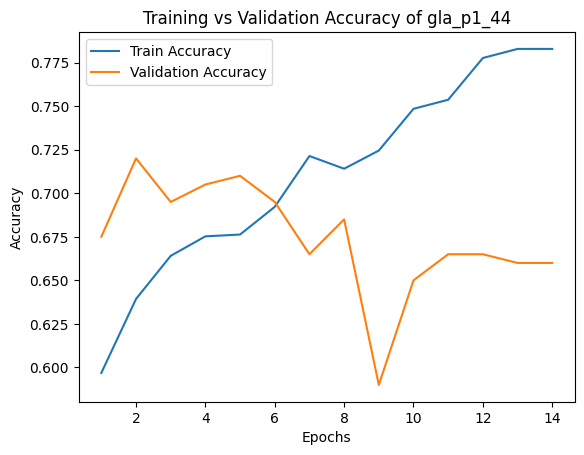

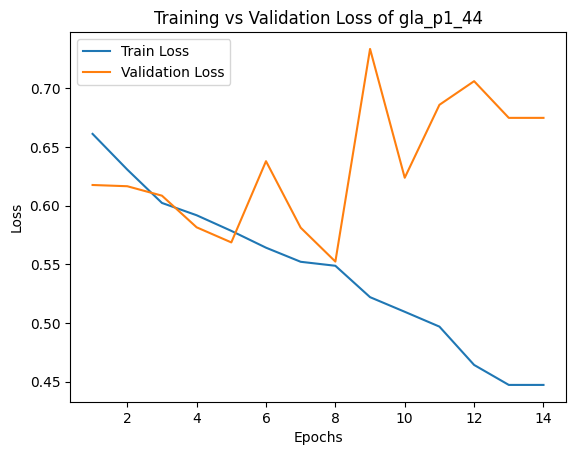

In [61]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy of gla_p1_44')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss of gla_p1_44')
plt.legend()
plt.show()


**Confusion Matrix**

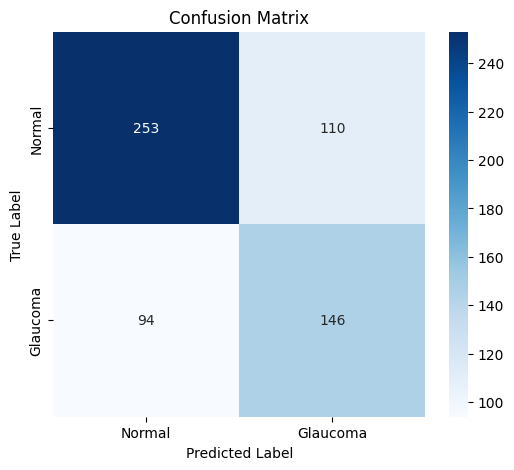

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

class_names = ["Normal", "Glaucoma"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [63]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      Normal       0.73      0.70      0.71       363
    Glaucoma       0.57      0.61      0.59       240

    accuracy                           0.66       603
   macro avg       0.65      0.65      0.65       603
weighted avg       0.67      0.66      0.66       603

